In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

import numpy as np

import matplotlib.pyplot as plt

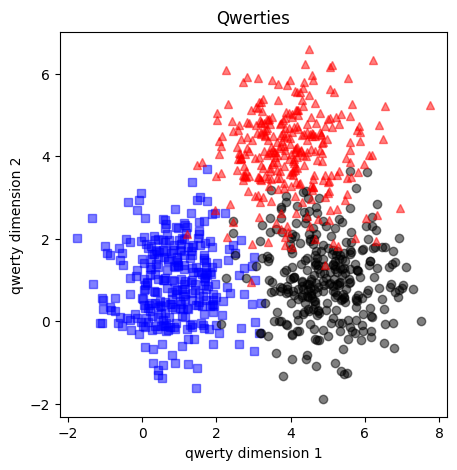

In [2]:
nPerClust = 300
blur = 1

A = [1,1]
B = [5,1]
C = [4,4]

a = [ A[0]+np.random.randn(nPerClust)*blur, A[1]+np.random.randn(nPerClust)*blur ]
b = [ B[0]+np.random.randn(nPerClust)*blur, B[1]+np.random.randn(nPerClust)*blur ]
c = [ C[0]+np.random.randn(nPerClust)*blur, C[1]+np.random.randn(nPerClust)*blur ]

labels_np = np.hstack((
    np.zeros((nPerClust)),
    np.ones((nPerClust)),
    1+np.ones((nPerClust))
))

data_np = np.hstack((a, b, c)).T

data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).long()

fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0], data[np.where(labels==0)[0],1], 'bs', alpha=.5)
plt.plot(data[np.where(labels==1)[0],0], data[np.where(labels==1)[0],1], 'ko', alpha=.5)
plt.plot(data[np.where(labels==2)[0],0], data[np.where(labels==2)[0],1], 'r^', alpha=.5)
plt.title('Qwerties')
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

In [3]:
# Separate the data
train_data, test_data, train_labels, test_labels = train_test_split(data, labels, test_size=0.2)

# Create Tensor Datasets
train_data = TensorDataset(train_data, train_labels)
test_data = TensorDataset(test_data, test_labels)

# Create Data Loaders
batchsize = 16
train_loader = DataLoader(train_data, batch_size=batchsize, shuffle=True, drop_last=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

In [9]:
def createTheQwertyNet(momentum):

    class qwertyNet(nn.Module):
        def __init__(self):
            super().__init__()
            # input layer
            self.input = nn.Linear(2,8)

            # hidden layer
            self.fc1 = nn.Linear(8,8)

            # output layer
            self.output = nn.Linear(8,3)

        def forward(self, x):
            x = F.relu( self.input(x) )
            x = F.relu( self.fc1(x) )
            return self.output(x)

    net = qwertyNet()

    lossfun = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(net.parameters(), lr=0.01, momentum=momentum)

    return net, lossfun, optimizer

In [11]:
numepochs = 50

def function2trainTheModel(momentum):

    net, lossfun, optimizer = createTheQwertyNet(momentum)

    losses = torch.zeros(numepochs)
    trainAcc = []
    testAcc = []

    for epochi in range(numepochs):

        # ===== Train =====
        net.train()

        batchAcc = []
        batchLoss = []
        for X, y in train_loader:

            # forward
            yHat = net(X)
            loss = lossfun(yHat, y)

            # backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # loss and accuracy
            batchLoss.append(loss.item())

            matches = torch.argmax(yHat, axis=1) == y
            matchesNumeric = matches.float()
            accuracyPct = 100*torch.mean(matchesNumeric)
            batchAcc.append( accuracyPct )

        trainAcc.append( np.mean(batchAcc) )

        losses[epochi] = np.mean(batchLoss)

        # ===== Test =====
        net.eval()
        X, y = next(iter(test_loader))
        with torch.no_grad():
            yHat = net(X)

        testAcc.append( 100*torch.mean((torch.argmax(yHat, axis=1)==y).float()) )

    return trainAcc, testAcc, losses, net

In [17]:
momenta = [.1, .2, .3, .4, .5, .6, .7, .8, .9]

results = np.zeros((numepochs, len(momenta), 3))

for idx, mom in enumerate(momenta):
    trainAcc, testAcc, losses, net = function2trainTheModel(mom)
    results[:, idx, 0] = losses
    results[:, idx, 1] = trainAcc
    results[:, idx, 2] = testAcc

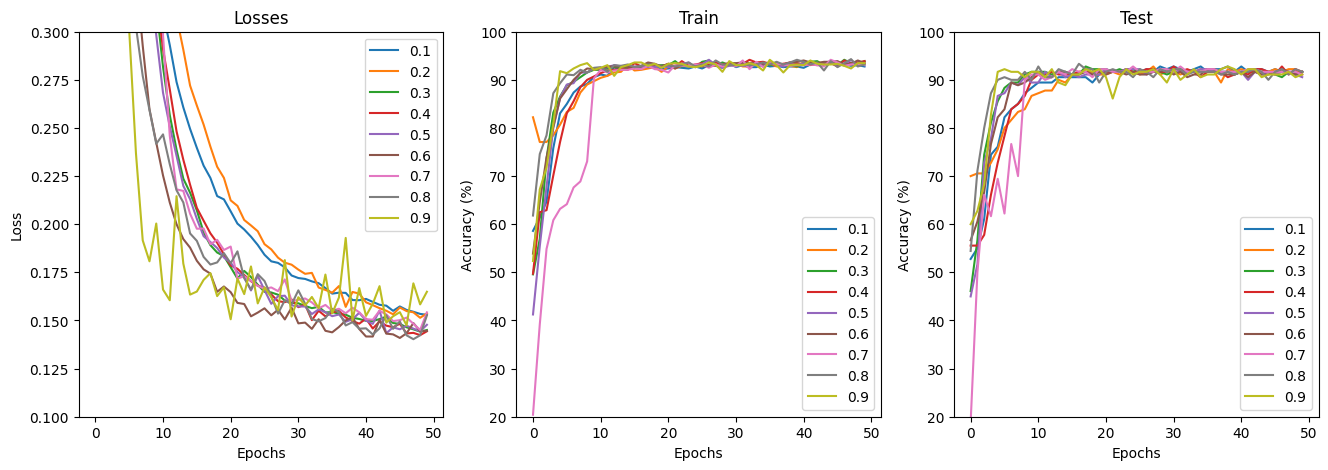

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(16,5))

for i in range(3):
    ax[i].plot(results[:,:,i])
    ax[i].legend(momenta)
    ax[i].set_xlabel('Epochs')
    if i == 0:
        ax[i].set_ylabel('Loss')
        ax[i].set_ylim([.1,.3])
    else:
        ax[i].set_ylabel('Accuracy (%)')
        ax[i].set_ylim([20, 100])

ax[0].set_title('Losses')
ax[1].set_title('Train')
ax[2].set_title('Test')

plt.show()